Sección A — Setup, carga y visualización de la serie

=== DATASET ===
Periodo: 2002-01-01 → 2025-12-01
Shape:   (288, 9)

Primeras filas:
            year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  \
fecha                                                                         
2002-01-01  2002      1                    84.60                      824.0   
2002-02-01  2002      2                    82.96                      808.0   
2002-03-01  2002      3                    79.88                      778.0   

            precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop  
fecha                                                                        
2002-01-01     118.09       0.80         0.82      0.89            276480.0  
2002-02-01     135.23       0.75         0.78      0.87            270960.0  
2002-03-01     234.07       0.68         0.73      0.85            296859.0  


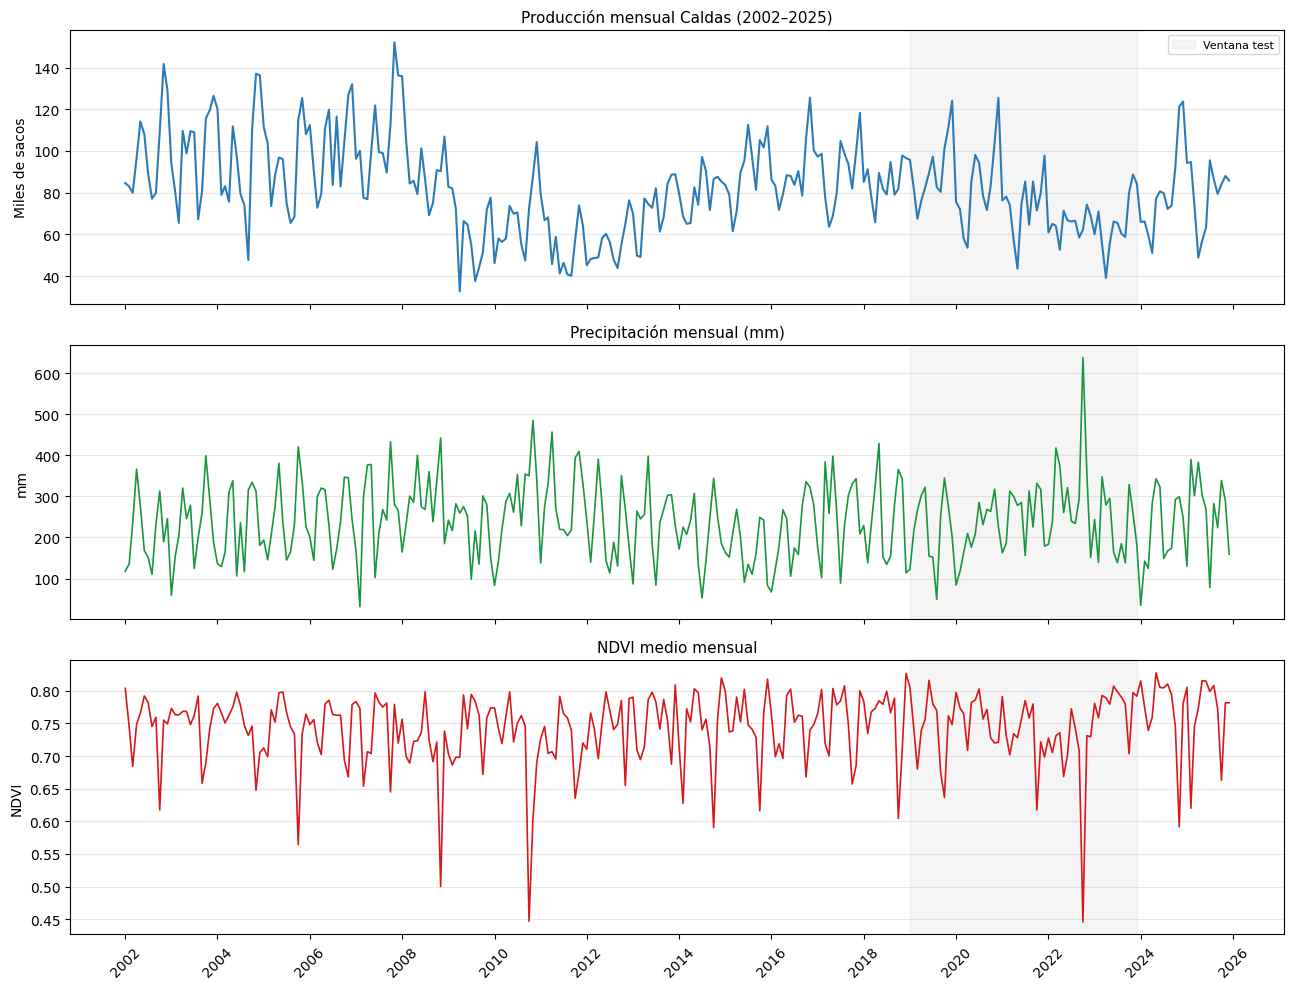

Gráfica guardada: sA_serie_temporal.png

=== PRODUCCIÓN CALDAS — ESTADÍSTICA POR AÑO ===
       total_anual  media_mensual  min_mensual  max_mensual
fecha                                                      
2002        1192.4           99.4         77.1        141.7
2003        1175.7           98.0         65.5        126.4
2004        1152.0           96.0         47.7        137.0
2005        1126.8           93.9         65.5        125.4
2006        1232.0          102.7         72.7        132.0
2007        1261.0          105.1         76.9        152.1
2008        1110.2           92.5         69.2        135.8
2009         738.2           61.5         32.6         82.8
2010         799.4           66.6         46.1        104.3
2011         682.7           56.9         40.1         79.4
2012         653.6           54.5         43.8         76.3
2013         866.8           72.2         49.1         88.8
2014         953.9           79.5         65.1         97.1
2015       

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# --- A.1 Carga e indexado temporal ---
df = pd.read_csv('cafe_seguro_master.csv', parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df = df.set_index('fecha')
df.index.freq = 'MS'  # frecuencia mensual inicio de mes

print("=== DATASET ===")
print(f"Periodo: {df.index.min().date()} → {df.index.max().date()}")
print(f"Shape:   {df.shape}")
print(f"\nPrimeras filas:")
print(df.head(3).round(2))

# --- A.2 Visualización de la serie objetivo ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1 — Producción Caldas
axes[0].plot(df.index, df['prod_caldas_miles_sacos'],
             color='#2c7bb6', lw=1.5)
axes[0].set_ylabel('Miles de sacos')
axes[0].set_title('Producción mensual Caldas (2002–2025)', fontsize=11)
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray', label='Ventana test')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2 — Precipitación
axes[1].plot(df.index, df['precip_mm'],
             color='#1a9641', lw=1.2)
axes[1].set_ylabel('mm')
axes[1].set_title('Precipitación mensual (mm)', fontsize=11)
axes[1].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[1].grid(axis='y', alpha=0.3)

# Panel 3 — NDVI mean
axes[2].plot(df.index, df['ndvi_mean'],
             color='#d7191c', lw=1.2)
axes[2].set_ylabel('NDVI')
axes[2].set_title('NDVI medio mensual', fontsize=11)
axes[2].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[2].grid(axis='y', alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sA_serie_temporal.png', dpi=150)
plt.show()
print("Gráfica guardada: sA_serie_temporal.png")

# --- A.3 Estadística descriptiva por componente ---
print("\n=== PRODUCCIÓN CALDAS — ESTADÍSTICA POR AÑO ===")
resumen_anual = (df['prod_caldas_miles_sacos']
                 .resample('YE')
                 .agg(['sum','mean','min','max'])
                 .round(1))
resumen_anual.index = resumen_anual.index.year
resumen_anual.columns = ['total_anual','media_mensual','min_mensual','max_mensual']
print(resumen_anual.to_string())

Sección B — Feature Engineering

In [2]:
# --- B.1 Variable de tendencia ---
# Tendencia lineal: contador desde 1 hasta N
# Tendencia cuadrática: para capturar la caída 2009-2013 y recuperación
df = df.reset_index()  # sacamos fecha del índice para manipular
df['t']  = np.arange(1, len(df) + 1)          # tendencia lineal
df['t2'] = df['t'] ** 2                        # tendencia cuadrática

print("=== TENDENCIA ===")
print(df[['fecha','t','t2']].head(4).to_string(index=False))
print(f"... t va de 1 a {df['t'].max()}")

=== TENDENCIA ===
     fecha  t  t2
2002-01-01  1   1
2002-02-01  2   4
2002-03-01  3   9
2002-04-01  4  16
... t va de 1 a 288


In [3]:
# --- B.2 Dummies de estacionalidad mensual ---
# 12 dummies, una por mes — captura el patrón cosecha/mitaca
# Usamos get_dummies y eliminamos enero como categoría base (evita multicolinealidad)
dummies_mes = pd.get_dummies(df['month'], prefix='mes', drop_first=True, dtype=int)
df = pd.concat([df, dummies_mes], axis=1)

meses_dummy = [c for c in df.columns if c.startswith('mes_')]
print(f"\n=== DUMMIES ESTACIONALIDAD ===")
print(f"Variables creadas: {meses_dummy}")
print(df[['fecha','month'] + meses_dummy].head(6).to_string(index=False))




=== DUMMIES ESTACIONALIDAD ===
Variables creadas: ['mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
     fecha  month  mes_2  mes_3  mes_4  mes_5  mes_6  mes_7  mes_8  mes_9  mes_10  mes_11  mes_12
2002-01-01      1      0      0      0      0      0      0      0      0       0       0       0
2002-02-01      2      1      0      0      0      0      0      0      0       0       0       0
2002-03-01      3      0      1      0      0      0      0      0      0       0       0       0
2002-04-01      4      0      0      1      0      0      0      0      0       0       0       0
2002-05-01      5      0      0      0      1      0      0      0      0       0       0       0
2002-06-01      6      0      0      0      0      1      0      0      0       0       0       0


In [4]:
# --- B.3 Rezagos de variables climáticas ---
# El efecto de lluvia y vegetación sobre producción no es inmediato
# En café: floración → desarrollo → cosecha toma 6-9 meses
# Pero a nivel mensual los rezagos 1-3 capturan señales de corto plazo
# Rezagos de precipitación
for lag in [1, 2, 3]:
    df[f'precip_lag{lag}'] = df['precip_mm'].shift(lag)

# Rezagos de NDVI mean
for lag in [1, 2, 3]:
    df[f'ndvi_lag{lag}'] = df['ndvi_mean'].shift(lag)

# Rezagos de NDVI p90 (captura vigor de la vegetación en zona alta)
for lag in [1, 2, 3]:
    df[f'ndvi_p90_lag{lag}'] = df['ndvi_p90'].shift(lag)

lags_creados = [c for c in df.columns if 'lag' in c]
print(f"\n=== REZAGOS CLIMÁTICOS ===")
print(f"Variables creadas: {lags_creados}")
print(df[['fecha'] + lags_creados].head(6).round(3).to_string(index=False))
print(f"\nNota: primeras 3 filas tienen NaN por construcción del rezago — se eliminan al partir train/test")




=== REZAGOS CLIMÁTICOS ===
Variables creadas: ['precip_lag1', 'precip_lag2', 'precip_lag3', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'ndvi_p90_lag1', 'ndvi_p90_lag2', 'ndvi_p90_lag3']
     fecha  precip_lag1  precip_lag2  precip_lag3  ndvi_lag1  ndvi_lag2  ndvi_lag3  ndvi_p90_lag1  ndvi_p90_lag2  ndvi_p90_lag3
2002-01-01          NaN          NaN          NaN        NaN        NaN        NaN            NaN            NaN            NaN
2002-02-01      118.092          NaN          NaN      0.804        NaN        NaN          0.889            NaN            NaN
2002-03-01      135.231      118.092          NaN      0.745      0.804        NaN          0.865          0.889            NaN
2002-04-01      234.066      135.231      118.092      0.684      0.745      0.804          0.846          0.865          0.889
2002-05-01      366.398      234.066      135.231      0.749      0.684      0.745          0.865          0.846          0.865
2002-06-01      275.821      366.398      234.066

In [5]:
# --- B.4 Eliminar filas con NaN generados por rezagos ---
df_model = df.dropna().copy()
print(f"\n=== SHAPE DESPUÉS DE ELIMINAR NaN ===")
print(f"Original: {len(df)} filas")
print(f"Modelo:   {len(df_model)} filas (se eliminaron {len(df)-len(df_model)} por rezagos)")
print(f"Periodo resultante: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}")




=== SHAPE DESPUÉS DE ELIMINAR NaN ===
Original: 288 filas
Modelo:   285 filas (se eliminaron 3 por rezagos)
Periodo resultante: 2002-04-01 → 2025-12-01


In [6]:
# --- B.5 Definición de features por modelo ---
# Cuatro especificaciones que vamos a comparar

FEATURES = {
    'M1_tendencia': ['t'],
    'M2_tendencia_poly': ['t', 't2'],
    'M3_estacionalidad': ['t'] + meses_dummy,
    'M4_completo': ['t', 't2'] + meses_dummy + lags_creados
}

TARGET = 'prod_caldas_miles_sacos'

print("\n=== ESPECIFICACIONES DE MODELOS ===")
for nombre, features in FEATURES.items():
    print(f"{nombre}: {len(features)} variables → {features}")




=== ESPECIFICACIONES DE MODELOS ===
M1_tendencia: 1 variables → ['t']
M2_tendencia_poly: 2 variables → ['t', 't2']
M3_estacionalidad: 12 variables → ['t', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
M4_completo: 22 variables → ['t', 't2', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'ndvi_p90_lag1', 'ndvi_p90_lag2', 'ndvi_p90_lag3']


In [7]:
# --- B.6 Correlación de rezagos con producción ---
print("\n=== CORRELACIÓN REZAGOS vs PRODUCCIÓN CALDAS ===")
cols_corr = [TARGET] + lags_creados
corr = df_model[cols_corr].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr.round(3).to_string())


=== CORRELACIÓN REZAGOS vs PRODUCCIÓN CALDAS ===
precip_lag1      0.216
precip_lag2      0.144
ndvi_lag3       -0.006
precip_lag3     -0.051
ndvi_p90_lag1   -0.061
ndvi_lag2       -0.131
ndvi_p90_lag2   -0.132
ndvi_lag1       -0.177
ndvi_p90_lag3   -0.188


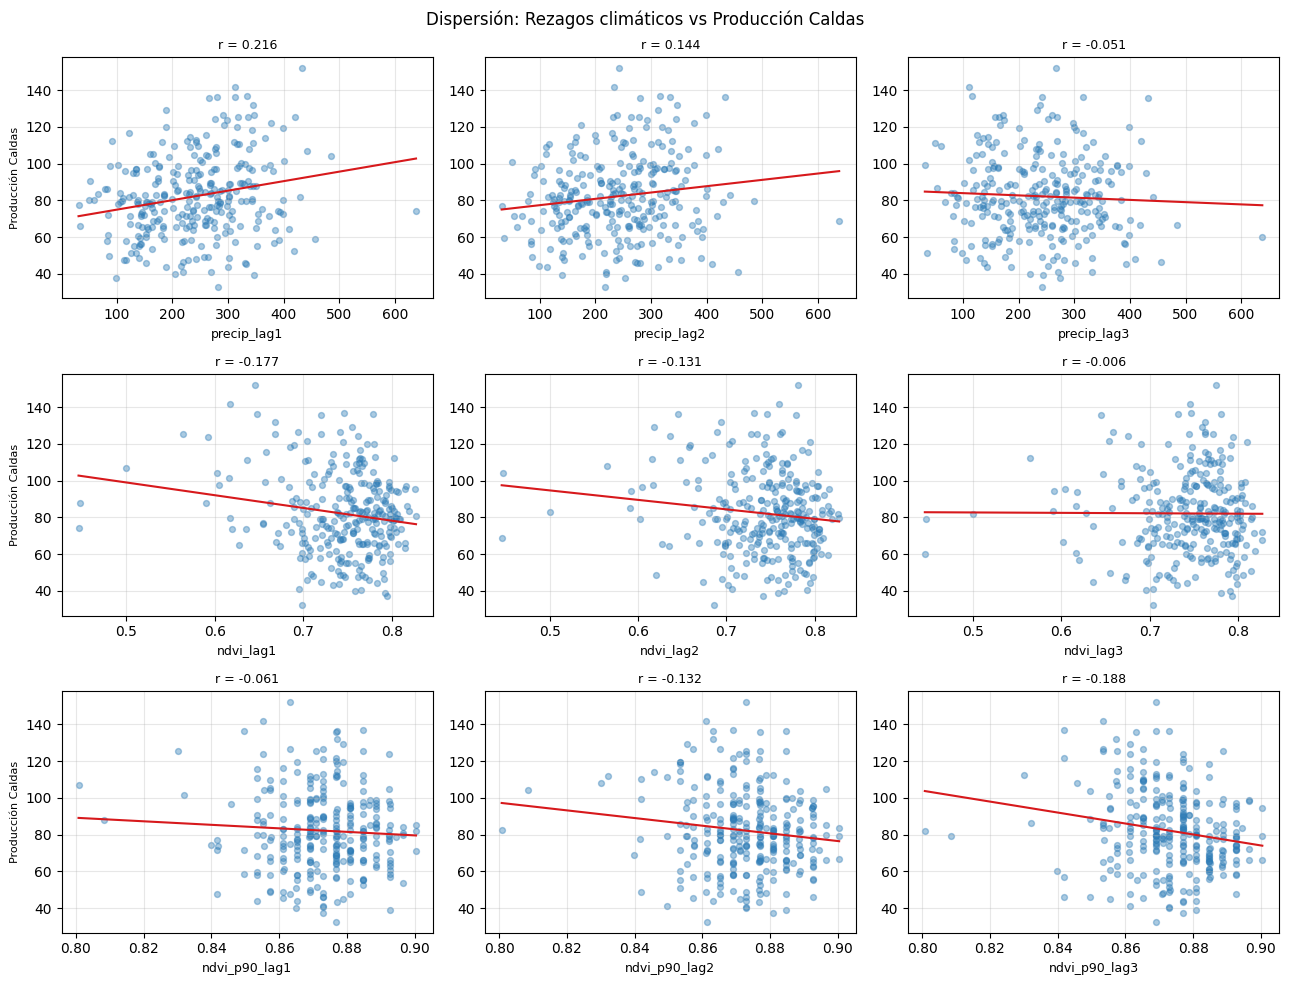

Gráfica guardada: sB_correlacion_rezagos.png


In [9]:
# --- B.7 — grid 3x3 para 9 rezagos ---
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, lag_var in enumerate(lags_creados):
    axes[i].scatter(df_model[lag_var], df_model[TARGET],
                    alpha=0.4, s=18, color='#2c7bb6')
    z = np.polyfit(df_model[lag_var].dropna(), df_model[TARGET].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_model[lag_var].min(), df_model[lag_var].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#d7191c', lw=1.5)
    axes[i].set_xlabel(lag_var, fontsize=9)
    axes[i].set_ylabel('Producción Caldas' if i % 3 == 0 else '', fontsize=8)
    axes[i].set_title(f'r = {df_model[[lag_var, TARGET]].corr().iloc[0,1]:.3f}', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Dispersión: Rezagos climáticos vs Producción Caldas', fontsize=12)
plt.tight_layout()
plt.savefig('sB_correlacion_rezagos.png', dpi=150)
plt.show()
print("Gráfica guardada: sB_correlacion_rezagos.png")

Sección C — Partición train/test

In [14]:

# --- C.1 Partición temporal ---
# Train: 2002-04 a 2018-12  (después de eliminar NaN por rezagos)
# Test:  2019-01 a 2023-12  (60 meses, out-of-sample)
# Demo:  2024-01 a 2025-12  (reservado para artefacto)

train = df_model[df_model['year'] <= 2018].copy()
test  = df_model[(df_model['year'] >= 2019) & (df_model['year'] <= 2023)].copy()
demo  = df_model[df_model['year'] >= 2024].copy()

print("=== PARTICIÓN WALK-FORWARD ===")
print(f"Train: {train['fecha'].min().date()} → {train['fecha'].max().date()} | {len(train)} meses")
print(f"Test:  {test['fecha'].min().date()}  → {test['fecha'].max().date()}  | {len(test)} meses")
print(f"Demo:  {demo['fecha'].min().date()}  → {demo['fecha'].max().date()}  | {len(demo)} meses")
print(f"Total: {len(train)+len(test)+len(demo)} meses")



=== PARTICIÓN WALK-FORWARD ===
Train: 2002-04-01 → 2018-12-01 | 201 meses
Test:  2019-01-01  → 2023-12-01  | 60 meses
Demo:  2024-01-01  → 2025-12-01  | 24 meses
Total: 285 meses


In [11]:
# --- C.2 Matrices X e y por split ---
resultados = {}  # diccionario para guardar modelos y métricas

for nombre, features in FEATURES.items():
    X_train = train[features]
    X_test  = test[features]
    y_train = train[TARGET]
    y_test  = test[TARGET]
    resultados[nombre] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'features': features
    }

print("\n=== SHAPES POR MODELO ===")
for nombre, d in resultados.items():
    print(f"{nombre}: X_train{d['X_train'].shape} | X_test{d['X_test'].shape}")



=== SHAPES POR MODELO ===
M1_tendencia: X_train(201, 1) | X_test(60, 1)
M2_tendencia_poly: X_train(201, 2) | X_test(60, 2)
M3_estacionalidad: X_train(201, 12) | X_test(60, 12)
M4_completo: X_train(201, 22) | X_test(60, 22)


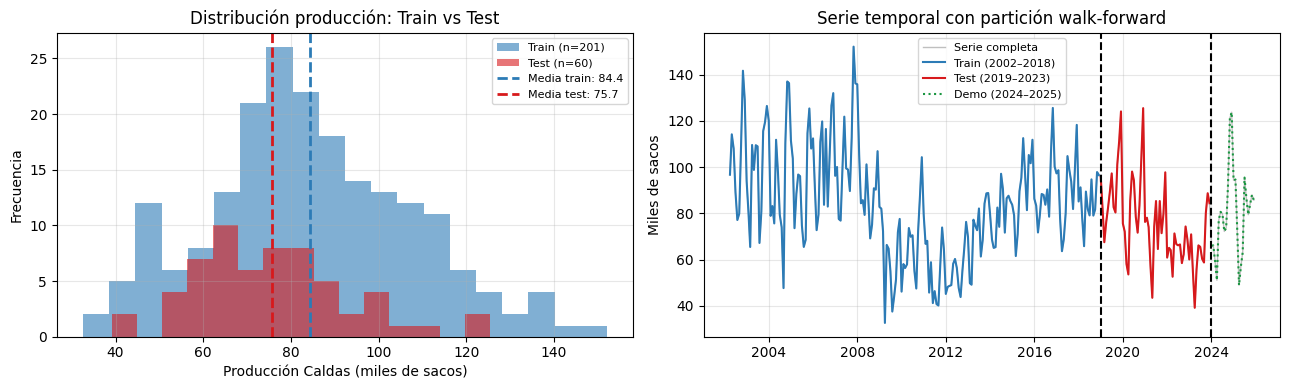

In [12]:
# --- C.3 Verificación de distribución train vs test ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución producción train vs test
axes[0].hist(train[TARGET], bins=20, alpha=0.6, color='#2c7bb6', label=f'Train (n={len(train)})')
axes[0].hist(test[TARGET],  bins=15, alpha=0.6, color='#d7191c', label=f'Test (n={len(test)})')
axes[0].axvline(train[TARGET].mean(), color='#2c7bb6', lw=2, linestyle='--',
                label=f'Media train: {train[TARGET].mean():.1f}')
axes[0].axvline(test[TARGET].mean(),  color='#d7191c', lw=2, linestyle='--',
                label=f'Media test: {test[TARGET].mean():.1f}')
axes[0].set_xlabel('Producción Caldas (miles de sacos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución producción: Train vs Test')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Serie temporal con cortes marcados
axes[1].plot(df_model['fecha'], df_model[TARGET],
             color='gray', lw=1, alpha=0.5, label='Serie completa')
axes[1].plot(train['fecha'], train[TARGET],
             color='#2c7bb6', lw=1.5, label='Train (2002–2018)')
axes[1].plot(test['fecha'],  test[TARGET],
             color='#d7191c', lw=1.5, label='Test (2019–2023)')
axes[1].plot(demo['fecha'],  demo[TARGET],
             color='#1a9641', lw=1.5, linestyle=':', label='Demo (2024–2025)')
axes[1].axvline(pd.Timestamp('2019-01-01'), color='black', lw=1.5, linestyle='--')
axes[1].axvline(pd.Timestamp('2024-01-01'), color='black', lw=1.5, linestyle='--')
axes[1].set_ylabel('Miles de sacos')
axes[1].set_title('Serie temporal con partición walk-forward')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sC_particion_train_test.png', dpi=150)
plt.show()



In [13]:
# --- C.4 Estadística comparativa train vs test ---
print("\n=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===")
comp = pd.DataFrame({
    'Train (2002–2018)': train[TARGET].describe(),
    'Test  (2019–2023)': test[TARGET].describe()
}).round(2)
print(comp.to_string())

print("\n Partición lista — avanzar a Sección D: Entrenamiento de modelos")


=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===
       Train (2002–2018)  Test  (2019–2023)
count             201.00              60.00
mean               84.44              75.65
std                23.23              17.50
min                32.60              39.14
25%                69.16              64.44
50%                82.50              74.16
75%                98.94              84.62
max               152.11             125.50

 Partición lista — avanzar a Sección D: Entrenamiento de modelos


Sección D — Entrenamiento de los 4 modelos con statsmodels

In [15]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- D.1 Función auxiliar de métricas ---
def calcular_metricas(y_real, y_pred, nombre, split):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - y_real.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {'modelo': nombre, 'split': split,
            'RMSE': round(rmse, 3),
            'MAPE': round(mape, 3),
            'R2':   round(r2, 3)}

In [16]:
# --- D.2 Entrenamiento de los 4 modelos ---
metricas_todas = []

for nombre, d in resultados.items():

    # Agregar constante (intercepto) — requerido en statsmodels
    X_train_sm = sm.add_constant(d['X_train'])
    X_test_sm  = sm.add_constant(d['X_test'])

    # Ajuste del modelo
    modelo = sm.OLS(d['y_train'], X_train_sm).fit()

    # Predicciones
    y_pred_train = modelo.predict(X_train_sm)
    y_pred_test  = modelo.predict(X_test_sm)

    # Guardar modelo y predicciones
    resultados[nombre]['modelo']       = modelo
    resultados[nombre]['y_pred_train'] = y_pred_train
    resultados[nombre]['y_pred_test']  = y_pred_test

    # Métricas train y test
    metricas_todas.append(calcular_metricas(d['y_train'], y_pred_train, nombre, 'train'))
    metricas_todas.append(calcular_metricas(d['y_test'],  y_pred_test,  nombre, 'test'))

    print(f"\n{'='*60}")
    print(f"MODELO: {nombre}")
    print(f"{'='*60}")
    print(f"Obs train: {len(d['y_train'])} | Variables: {len(d['features'])}")
    print(f"R² train:  {modelo.rsquared:.4f}")
    print(f"AIC:       {modelo.aic:.2f}")
    print(f"BIC:       {modelo.bic:.2f}")
    print(modelo.summary2().tables[1].round(4))




MODELO: M1_tendencia
Obs train: 201 | Variables: 1
R² train:  0.0615
AIC:       1825.12
BIC:       1831.72
         Coef.  Std.Err.       t   P>|t|   [0.025    0.975]
const  94.7405    3.2661  29.007  0.0000  88.2998  101.1811
t      -0.0991    0.0274  -3.612  0.0004  -0.1531   -0.0450

MODELO: M2_tendencia_poly
Obs train: 201 | Variables: 2
R² train:  0.2208
AIC:       1789.73
BIC:       1799.64
          Coef.  Std.Err.        t  P>|t|    [0.025    0.975]
const  117.6210    4.6727  25.1720    0.0  108.4063  126.8356
t       -0.7379    0.1035  -7.1304    0.0   -0.9420   -0.5338
t2       0.0031    0.0005   6.3624    0.0    0.0021    0.0040

MODELO: M3_estacionalidad
Obs train: 201 | Variables: 12
R² train:  0.3322
AIC:       1778.72
BIC:       1821.67
          Coef.  Std.Err.        t   P>|t|   [0.025    0.975]
const   99.7159    5.4754  18.2115  0.0000  88.9147  110.5171
t       -0.1035    0.0238  -4.3431  0.0000  -0.1504   -0.0565
mes_2   -8.6751    6.9226  -1.2532  0.2117 -22.3310

In [17]:
# --- D.3 Tabla comparativa de métricas ---
df_metricas = pd.DataFrame(metricas_todas)
df_pivot = df_metricas.pivot(index='modelo', columns='split',
                              values=['RMSE','MAPE','R2'])
df_pivot.columns = ['_'.join(c) for c in df_pivot.columns]
df_pivot = df_pivot[['RMSE_train','RMSE_test',
                      'MAPE_train','MAPE_test',
                      'R2_train',  'R2_test']]

print("\n")
print("="*70)
print("TABLA COMPARATIVA — 4 MODELOS")
print("="*70)
print(df_pivot.to_string())





TABLA COMPARATIVA — 4 MODELOS
                   RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
modelo                                                                            
M1_tendencia           22.448     17.135      25.027     16.736     0.062    0.025
M2_tendencia_poly      20.454     46.316      21.394     62.382     0.221   -6.124
M3_estacionalidad      18.936     14.057      21.169     14.571     0.332    0.344
M4_completo            16.453     43.610      17.494     56.563     0.496   -5.316


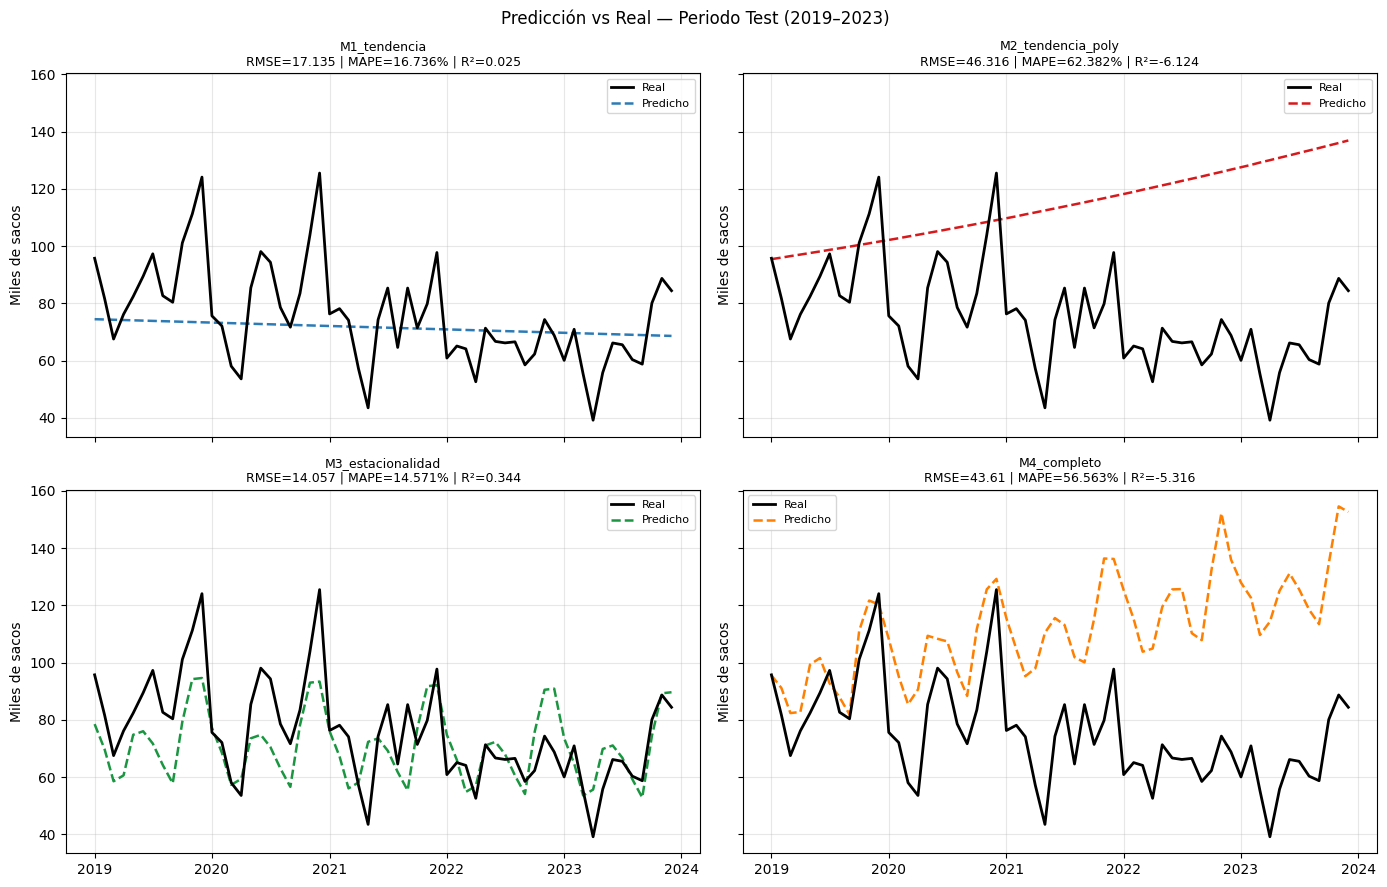

Gráfica guardada: sD_predicciones_test.png


In [18]:
# --- D.4 Visualización predicciones vs real en test ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

colores = ['#2c7bb6','#d7191c','#1a9641','#ff7f00']

for i, (nombre, d) in enumerate(resultados.items()):
    ax = axes[i]
    ax.plot(test['fecha'], d['y_test'].values,
            color='black', lw=2, label='Real', zorder=3)
    ax.plot(test['fecha'], d['y_pred_test'].values,
            color=colores[i], lw=1.8, linestyle='--', label='Predicho')

    # Métricas en el panel
    m = df_metricas[(df_metricas['modelo']==nombre) &
                    (df_metricas['split']=='test')].iloc[0]
    ax.set_title(f"{nombre}\nRMSE={m['RMSE']} | MAPE={m['MAPE']}% | R²={m['R2']}",
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylabel('Miles de sacos')

plt.suptitle('Predicción vs Real — Periodo Test (2019–2023)', fontsize=12)
plt.tight_layout()
plt.savefig('sD_predicciones_test.png', dpi=150)
plt.show()
print("Gráfica guardada: sD_predicciones_test.png")

Sección E — Verificación de supuestos del modelo ganador (M3)

In [19]:
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

modelo_m3 = resultados['M3_estacionalidad']['modelo']
X_train_m3 = sm.add_constant(resultados['M3_estacionalidad']['X_train'])
y_train_m3 = resultados['M3_estacionalidad']['y_train']

# Residuos
residuos = modelo_m3.resid
fitted   = modelo_m3.fittedvalues

print("=" * 60)
print("VERIFICACIÓN DE SUPUESTOS — M3_estacionalidad")
print("=" * 60)



VERIFICACIÓN DE SUPUESTOS — M3_estacionalidad


In [22]:
# ─────────────────────────────────────────────
# E.1 Supuesto 1: Normalidad de residuos
# ─────────────────────────────────────────────
stat_sw, p_sw   = stats.shapiro(residuos)
resultado_jb = stats.jarque_bera(residuos)
stat_jb = resultado_jb.statistic
p_jb    = resultado_jb.pvalue

print("\n--- SUPUESTO 1: NORMALIDAD DE RESIDUOS ---")
print(f"Shapiro-Wilk:  W={stat_sw:.4f} | p={p_sw:.4f} → {' Normal' if p_sw > 0.05 else '  No normal'}")
print(f"Jarque-Bera:   JB={stat_jb:.4f} | p={p_jb:.4f} → {' Normal' if p_jb > 0.05 else '  No normal'}")




--- SUPUESTO 1: NORMALIDAD DE RESIDUOS ---
Shapiro-Wilk:  W=0.9846 | p=0.0275 →   No normal
Jarque-Bera:   JB=4.4613 | p=0.1075 →  Normal


In [23]:
# ─────────────────────────────────────────────
# E.2 Supuesto 2: Homocedasticidad
# ─────────────────────────────────────────────
bp_lm, bp_p, _, _ = het_breuschpagan(residuos, X_train_m3)

print("\n--- SUPUESTO 2: HOMOCEDASTICIDAD ---")
print(f"Breusch-Pagan: LM={bp_lm:.4f} | p={bp_p:.4f} → {' Homoced.' if bp_p > 0.05 else '  Heteroced.'}")




--- SUPUESTO 2: HOMOCEDASTICIDAD ---
Breusch-Pagan: LM=15.2232 | p=0.2295 →  Homoced.


In [24]:
# ─────────────────────────────────────────────
# E.3 Supuesto 3: No autocorrelación de residuos
# ─────────────────────────────────────────────
dw = durbin_watson(residuos)
ljung = acorr_ljungbox(residuos, lags=[6, 12, 24], return_df=True)

print("\n--- SUPUESTO 3: NO AUTOCORRELACIÓN ---")
print(f"Durbin-Watson: {dw:.4f} → {' Sin autocorr.' if 1.5 < dw < 2.5 else '  Autocorrelación detectada'}")
print("Ljung-Box (lags 6, 12, 24):")
print(ljung[['lb_stat','lb_pvalue']].round(4).to_string())




--- SUPUESTO 3: NO AUTOCORRELACIÓN ---
Durbin-Watson: 0.5356 →   Autocorrelación detectada
Ljung-Box (lags 6, 12, 24):
      lb_stat  lb_pvalue
6    468.1263        0.0
12   764.0900        0.0
24  1024.4673        0.0


In [25]:
# ─────────────────────────────────────────────
# E.4 Supuesto 4: No multicolinealidad (VIF)
# ─────────────────────────────────────────────
print("\n--- SUPUESTO 4: MULTICOLINEALIDAD (VIF) ---")
vif_data = pd.DataFrame()
vif_data['variable'] = X_train_m3.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_m3.values, i)
                   for i in range(X_train_m3.shape[1])]
vif_data['estado'] = vif_data['VIF'].apply(
    lambda v: ' OK' if v < 5 else ('  Moderado' if v < 10 else ' Alto'))
print(vif_data.round(2).to_string(index=False))




--- SUPUESTO 4: MULTICOLINEALIDAD (VIF) ---
variable   VIF estado
   const 15.72   Alto
       t  1.00     OK
   mes_2  1.84     OK
   mes_3  1.84     OK
   mes_4  1.89     OK
   mes_5  1.89     OK
   mes_6  1.89     OK
   mes_7  1.89     OK
   mes_8  1.89     OK
   mes_9  1.89     OK
  mes_10  1.89     OK
  mes_11  1.89     OK
  mes_12  1.89     OK


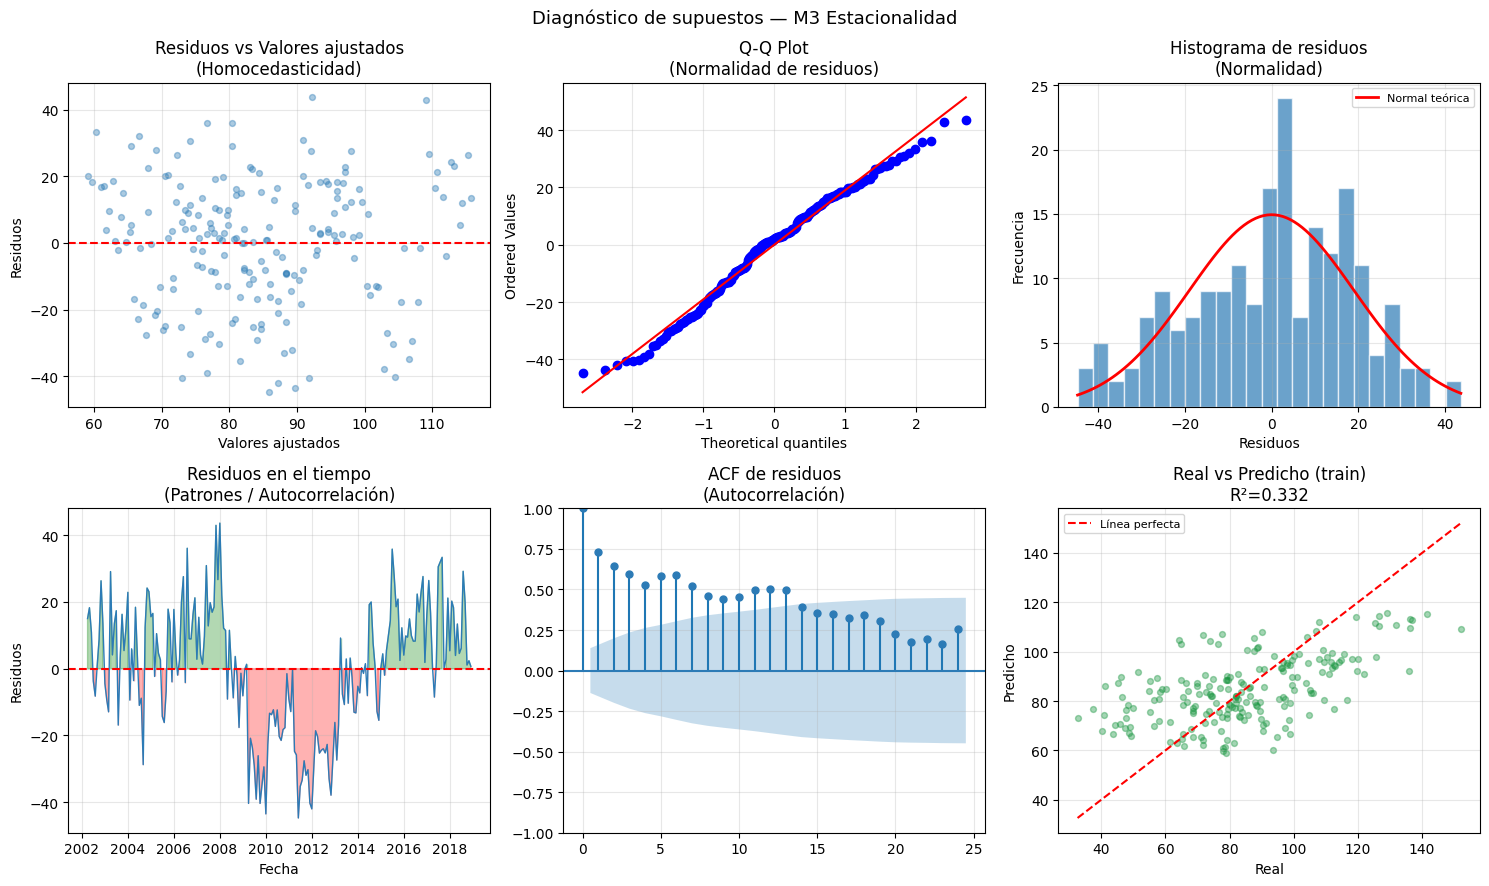

Gráfica guardada: sE_supuestos_m3.png


In [26]:
# ─────────────────────────────────────────────
# E.5 Panel de gráficas diagnósticas
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Panel 1 — Residuos vs Fitted
axes[0,0].scatter(fitted, residuos, alpha=0.4, s=18, color='#2c7bb6')
axes[0,0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0,0].set_xlabel('Valores ajustados')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs Valores ajustados\n(Homocedasticidad)')
axes[0,0].grid(alpha=0.3)

# Panel 2 — QQ Plot normalidad
stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot\n(Normalidad de residuos)')
axes[0,1].grid(alpha=0.3)

# Panel 3 — Histograma de residuos
axes[0,2].hist(residuos, bins=25, color='#2c7bb6', alpha=0.7, edgecolor='white')
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
axes[0,2].plot(x_norm,
               stats.norm.pdf(x_norm, residuos.mean(), residuos.std()) * len(residuos) * (residuos.max()-residuos.min())/25,
               'r-', lw=2, label='Normal teórica')
axes[0,2].set_xlabel('Residuos')
axes[0,2].set_ylabel('Frecuencia')
axes[0,2].set_title('Histograma de residuos\n(Normalidad)')
axes[0,2].legend(fontsize=8)
axes[0,2].grid(alpha=0.3)

# Panel 4 — Residuos en el tiempo
axes[1,0].plot(train['fecha'], residuos.values, color='#2c7bb6', lw=1)
axes[1,0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1,0].fill_between(train['fecha'],
                        residuos.values, 0,
                        where=(residuos.values > 0), alpha=0.3, color='green')
axes[1,0].fill_between(train['fecha'],
                        residuos.values, 0,
                        where=(residuos.values < 0), alpha=0.3, color='red')
axes[1,0].set_xlabel('Fecha')
axes[1,0].set_ylabel('Residuos')
axes[1,0].set_title('Residuos en el tiempo\n(Patrones / Autocorrelación)')
axes[1,0].grid(alpha=0.3)

# Panel 5 — ACF de residuos
plot_acf(residuos, lags=24, ax=axes[1,1], color='#2c7bb6', alpha=0.05)
axes[1,1].set_title('ACF de residuos\n(Autocorrelación)')
axes[1,1].grid(alpha=0.3)

# Panel 6 — Predicho vs Real (train)
axes[1,2].scatter(y_train_m3, fitted, alpha=0.4, s=18, color='#1a9641')
lims = [min(y_train_m3.min(), fitted.min()),
        max(y_train_m3.max(), fitted.max())]
axes[1,2].plot(lims, lims, 'r--', lw=1.5, label='Línea perfecta')
axes[1,2].set_xlabel('Real')
axes[1,2].set_ylabel('Predicho')
axes[1,2].set_title(f'Real vs Predicho (train)\nR²={modelo_m3.rsquared:.3f}')
axes[1,2].legend(fontsize=8)
axes[1,2].grid(alpha=0.3)

plt.suptitle('Diagnóstico de supuestos — M3 Estacionalidad', fontsize=13)
plt.tight_layout()
plt.savefig('sE_supuestos_m3.png', dpi=150)
plt.show()
print("Gráfica guardada: sE_supuestos_m3.png")



In [37]:
# ─────────────────────────────────────────────
# E.6 Resumen ejecutivo de supuestos
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("RESUMEN EJECUTIVO — SUPUESTOS M3")
print("="*60)
print(f"1. Normalidad    (Shapiro-Wilk):  {'' if p_sw  > 0.05 else ' '} p={p_sw:.4f}")
print(f"2. Homoced.      (Breusch-Pagan): {'' if bp_p  > 0.05 else ' '} p={bp_p:.4f}")
print(f"3. Autocorr.     (Durbin-Watson): {'' if 1.5 < dw < 2.5 else ' '} DW={dw:.4f}")
print(f"4. Multicolineal.(VIF máximo):    {'' if vif_data['VIF'][1:].max() < 10 else ' '} VIF_max={vif_data['VIF'][1:].max():.2f}")


RESUMEN EJECUTIVO — SUPUESTOS M3
1. Normalidad    (Shapiro-Wilk):    p=0.0275
2. Homoced.      (Breusch-Pagan):  p=0.2295
3. Autocorr.     (Durbin-Watson):   DW=0.5356
4. Multicolineal.(VIF máximo):     VIF_max=1.89


Sección F Pronóstico y estimación de pérdida

In [38]:

# ─────────────────────────────────────────────
# F.1 Predicciones en TEST (2019–2023)
# ─────────────────────────────────────────────
df_test_f = test[['fecha','month','year', TARGET]].copy()
df_test_f['pred_m3'] = resultados['M3_estacionalidad']['y_pred_test'].values

# Producción esperada = predicción del modelo
# Pérdida estimada = real - esperada (negativo = pérdida)
df_test_f['perdida_estimada'] = df_test_f[TARGET] - df_test_f['pred_m3']
df_test_f['perdida_pct']      = (df_test_f['perdida_estimada'] / df_test_f['pred_m3']) * 100

print("=== PREDICCIÓN vs REAL — TEST 2019–2023 ===")
print(df_test_f[['fecha','month', TARGET,
                  'pred_m3','perdida_estimada',
                  'perdida_pct']].round(2).to_string(index=False))



=== PREDICCIÓN vs REAL — TEST 2019–2023 ===
     fecha  month  prod_caldas_miles_sacos  pred_m3  perdida_estimada  perdida_pct
2019-01-01      1                    95.72    78.51             17.21        21.92
2019-02-01      2                    81.69    69.73             11.96        17.15
2019-03-01      3                    67.50    58.54              8.97        15.32
2019-04-01      4                    76.15    60.59             15.56        25.68
2019-05-01      5                    82.35    74.78              7.57        10.12
2019-06-01      6                    89.44    76.01             13.43        17.66
2019-07-01      7                    97.27    71.71             25.56        35.64
2019-08-01      8                    82.65    64.24             18.40        28.64
2019-09-01      9                    80.36    57.82             22.53        38.97
2019-10-01     10                   101.11    79.39             21.72        27.35
2019-11-01     11                   111.23 

In [39]:
# ─────────────────────────────────────────────
# F.2 Resumen de pérdidas por año
# ─────────────────────────────────────────────
print("\n=== RESUMEN ANUAL DE PÉRDIDAS — TEST ===")
resumen_anual = df_test_f.groupby('year').agg(
    prod_real_media    = (TARGET,             'mean'),
    prod_pred_media    = ('pred_m3',          'mean'),
    perdida_media      = ('perdida_estimada', 'mean'),
    perdida_pct_media  = ('perdida_pct',      'mean'),
    meses_con_perdida  = ('perdida_estimada', lambda x: (x < 0).sum()),
    peor_mes_perdida   = ('perdida_estimada', 'min')
).round(2)
print(resumen_anual.to_string())




=== RESUMEN ANUAL DE PÉRDIDAS — TEST ===
      prod_real_media  prod_pred_media  perdida_media  perdida_pct_media  meses_con_perdida  peor_mes_perdida
year                                                                                                         
2019            90.79            73.35          17.45              23.97                  0              7.57
2020            83.34            72.11          11.23              15.00                  2             -5.78
2021            73.96            70.86           3.09               6.33                  4            -28.83
2022            64.75            69.62          -4.87              -5.23                  8            -22.11
2023            65.41            68.38          -2.97              -4.19                  7            -16.48


In [40]:
# ─────────────────────────────────────────────
# F.3 Clasificación de severidad de pérdida
# ─────────────────────────────────────────────
# Umbral de pérdida severa: producción real cae más del 15%
# respecto a la producción esperada por el modelo
df_test_f['severidad'] = 'Normal'
df_test_f.loc[df_test_f['perdida_pct'] < -10, 'severidad'] = 'Pérdida moderada'
df_test_f.loc[df_test_f['perdida_pct'] < -20, 'severidad'] = 'Pérdida severa'

print("\n=== CLASIFICACIÓN DE SEVERIDAD ===")
print(df_test_f['severidad'].value_counts().to_string())
print()
print("Meses con pérdida severa (>20% bajo lo esperado):")
severos = df_test_f[df_test_f['severidad'] == 'Pérdida severa']
print(severos[['fecha','month', TARGET,
               'pred_m3','perdida_estimada',
               'perdida_pct']].round(2).to_string(index=False))




=== CLASIFICACIÓN DE SEVERIDAD ===
severidad
Normal              51
Pérdida moderada     5
Pérdida severa       4

Meses con pérdida severa (>20% bajo lo esperado):
     fecha  month  prod_caldas_miles_sacos  pred_m3  perdida_estimada  perdida_pct
2021-05-01      5                    43.47    72.30            -28.83       -39.88
2022-12-01     12                    68.78    90.89            -22.11       -24.33
2023-04-01      4                    39.14    55.62            -16.48       -29.62
2023-05-01      5                    55.77    69.82            -14.05       -20.12


In [41]:
# ─────────────────────────────────────────────
# F.4 Predicciones DEMO (2024–2025)
# ─────────────────────────────────────────────
X_demo_sm = sm.add_constant(
    demo[resultados['M3_estacionalidad']['features']]
)
df_demo_f = demo[['fecha','month','year', TARGET]].copy()
df_demo_f['pred_m3'] = (resultados['M3_estacionalidad']['modelo']
                        .predict(X_demo_sm).values)
df_demo_f['perdida_estimada'] = df_demo_f[TARGET] - df_demo_f['pred_m3']
df_demo_f['perdida_pct']      = (df_demo_f['perdida_estimada'] /
                                  df_demo_f['pred_m3']) * 100
df_demo_f['severidad'] = 'Normal'
df_demo_f.loc[df_demo_f['perdida_pct'] < -10, 'severidad'] = 'Pérdida moderada'
df_demo_f.loc[df_demo_f['perdida_pct'] < -20, 'severidad'] = 'Pérdida severa'

print("\n=== PRONÓSTICO DEMO 2024–2025 ===")
print(df_demo_f[['fecha','month', TARGET,'pred_m3',
                  'perdida_estimada','perdida_pct',
                  'severidad']].round(2).to_string(index=False))




=== PRONÓSTICO DEMO 2024–2025 ===
     fecha  month  prod_caldas_miles_sacos  pred_m3  perdida_estimada  perdida_pct        severidad
2024-01-01      1                    65.99    72.30             -6.32        -8.73           Normal
2024-02-01      2                    66.12    63.52              2.60         4.09           Normal
2024-03-01      3                    59.55    52.33              7.22        13.80           Normal
2024-04-01      4                    51.05    54.38             -3.33        -6.11           Normal
2024-05-01      5                    77.06    68.58              8.49        12.37           Normal
2024-06-01      6                    80.64    69.81             10.83        15.52           Normal
2024-07-01      7                    79.74    65.50             14.23        21.73           Normal
2024-08-01      8                    72.18    58.04             14.14        24.37           Normal
2024-09-01      9                    73.71    51.61             2

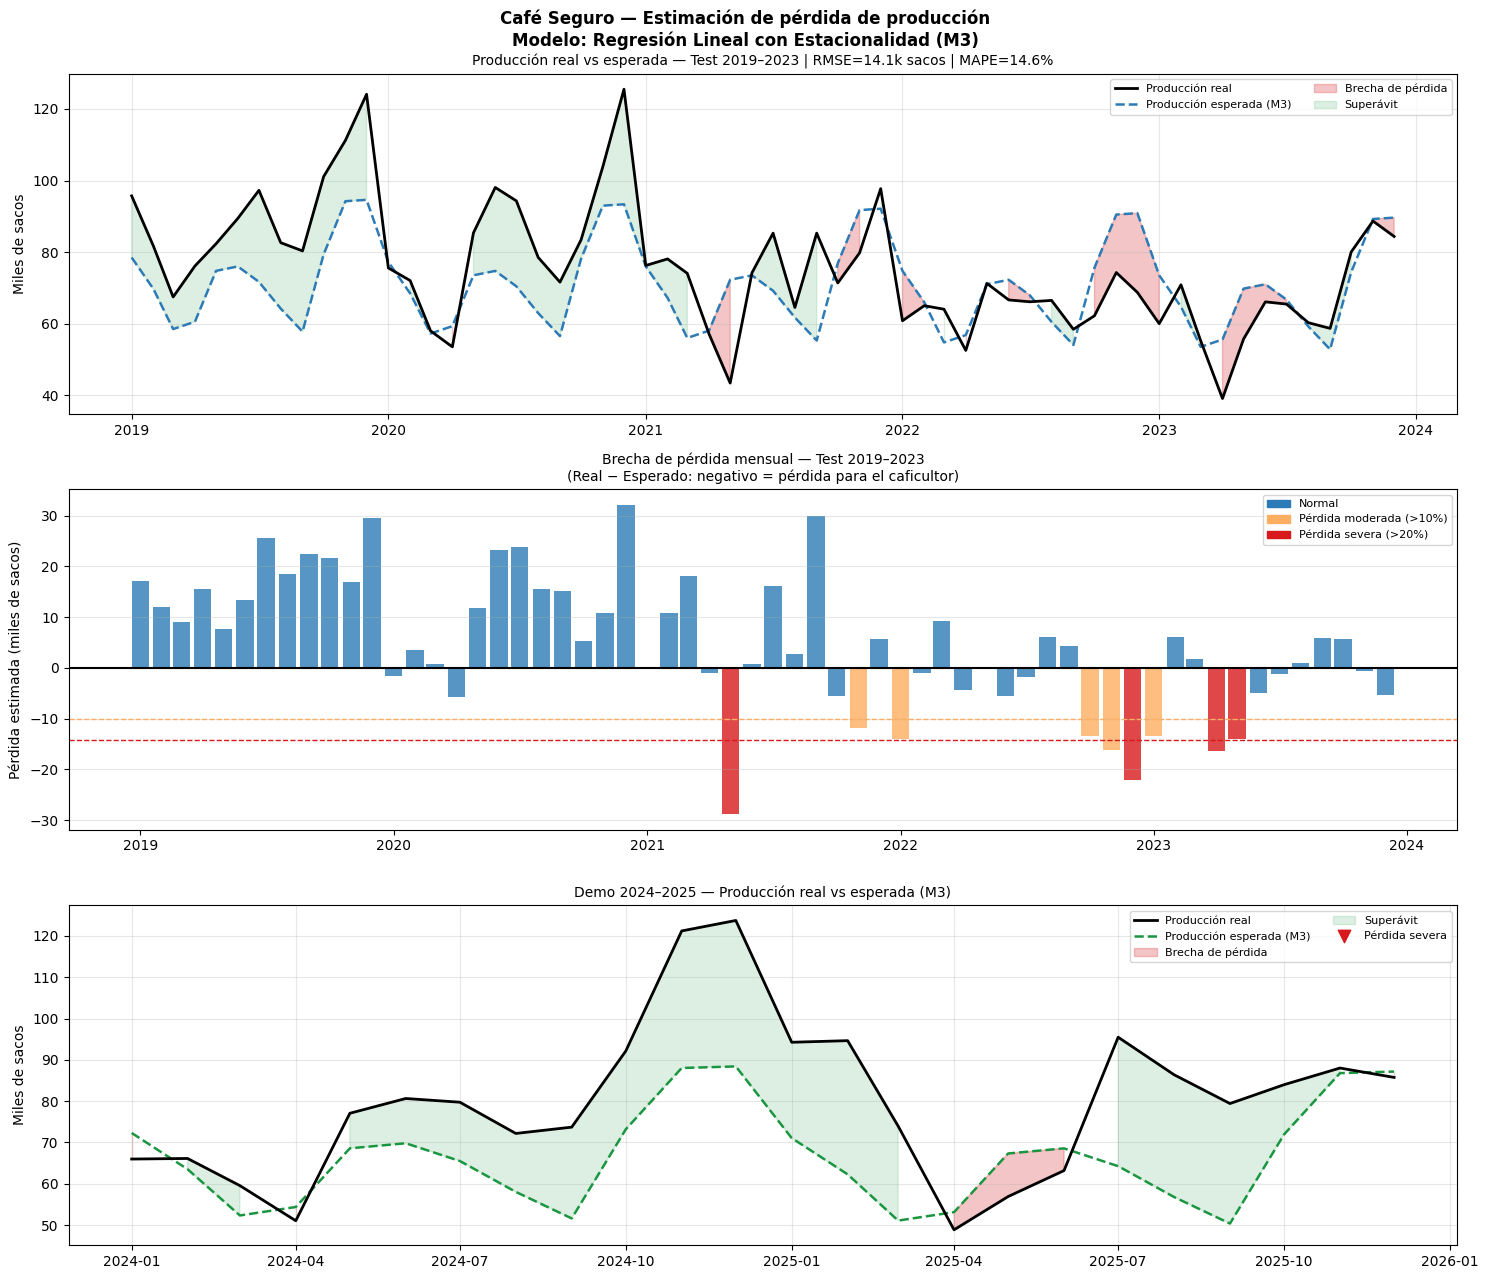

Gráfica guardada: sF_perdida_estimada.png


In [42]:
# ─────────────────────────────────────────────
# F.5 Visualización
# ─────────────────────────────────────────────
colores_sev = {'Normal': '#2c7bb6',
               'Pérdida moderada': '#fdae61',
               'Pérdida severa':   '#d7191c'}

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

# --- Panel 1: Predicción vs Real TEST ---
ax1 = axes[0]
ax1.plot(df_test_f['fecha'], df_test_f[TARGET],
         color='black', lw=2, label='Producción real', zorder=4)
ax1.plot(df_test_f['fecha'], df_test_f['pred_m3'],
         color='#2c7bb6', lw=1.8, linestyle='--',
         label='Producción esperada (M3)', zorder=3)
ax1.fill_between(df_test_f['fecha'],
                 df_test_f[TARGET], df_test_f['pred_m3'],
                 where=(df_test_f[TARGET] < df_test_f['pred_m3']),
                 alpha=0.25, color='#d7191c', label='Brecha de pérdida')
ax1.fill_between(df_test_f['fecha'],
                 df_test_f[TARGET], df_test_f['pred_m3'],
                 where=(df_test_f[TARGET] >= df_test_f['pred_m3']),
                 alpha=0.15, color='#1a9641', label='Superávit')

rmse_test = np.sqrt(mean_squared_error(df_test_f[TARGET], df_test_f['pred_m3']))
mape_test = mean_absolute_percentage_error(df_test_f[TARGET],
                                            df_test_f['pred_m3']) * 100
ax1.set_title(f'Producción real vs esperada — Test 2019–2023 | '
              f'RMSE={rmse_test:.1f}k sacos | MAPE={mape_test:.1f}%',
              fontsize=10)
ax1.set_ylabel('Miles de sacos')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

# --- Panel 2: Pérdida estimada TEST ---
ax2 = axes[1]
colores_barras = [colores_sev[s] for s in df_test_f['severidad']]
ax2.bar(df_test_f['fecha'], df_test_f['perdida_estimada'],
        color=colores_barras, alpha=0.8, width=25)
ax2.axhline(0, color='black', lw=1.5)
ax2.axhline(-10, color='#fdae61', lw=1, linestyle='--',
            label='Umbral pérdida moderada (−10%)')
ax2.axhline(df_test_f['pred_m3'].mean() * -0.20,
            color='#d7191c', lw=1, linestyle='--',
            label='Umbral pérdida severa (−20%)')

from matplotlib.patches import Patch
leyenda = [Patch(color='#2c7bb6', label='Normal'),
           Patch(color='#fdae61', label='Pérdida moderada (>10%)'),
           Patch(color='#d7191c', label='Pérdida severa (>20%)')]
ax2.legend(handles=leyenda, fontsize=8)
ax2.set_ylabel('Pérdida estimada (miles de sacos)')
ax2.set_title('Brecha de pérdida mensual — Test 2019–2023\n'
              '(Real − Esperado: negativo = pérdida para el caficultor)',
              fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# --- Panel 3: Demo 2024–2025 ---
ax3 = axes[2]
ax3.plot(df_demo_f['fecha'], df_demo_f[TARGET],
         color='black', lw=2, label='Producción real', zorder=4)
ax3.plot(df_demo_f['fecha'], df_demo_f['pred_m3'],
         color='#1a9641', lw=1.8, linestyle='--',
         label='Producción esperada (M3)', zorder=3)
ax3.fill_between(df_demo_f['fecha'],
                 df_demo_f[TARGET], df_demo_f['pred_m3'],
                 where=(df_demo_f[TARGET] < df_demo_f['pred_m3']),
                 alpha=0.25, color='#d7191c', label='Brecha de pérdida')
ax3.fill_between(df_demo_f['fecha'],
                 df_demo_f[TARGET], df_demo_f['pred_m3'],
                 where=(df_demo_f[TARGET] >= df_demo_f['pred_m3']),
                 alpha=0.15, color='#1a9641', label='Superávit')

# Marcar meses de pérdida severa
severos_d = df_demo_f[df_demo_f['severidad'] == 'Pérdida severa']
ax3.scatter(severos_d['fecha'], severos_d[TARGET],
            color='#d7191c', s=80, zorder=5,
            marker='v', label='Pérdida severa')

ax3.set_title('Demo 2024–2025 — Producción real vs esperada (M3)',
              fontsize=10)
ax3.set_ylabel('Miles de sacos')
ax3.legend(fontsize=8, ncol=2)
ax3.grid(alpha=0.3)

plt.suptitle('Café Seguro — Estimación de pérdida de producción\n'
             'Modelo: Regresión Lineal con Estacionalidad (M3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sF_perdida_estimada.png', dpi=150)
plt.show()
print("Gráfica guardada: sF_perdida_estimada.png")



In [43]:
# ─────────────────────────────────────────────
# F.6 Estadística de pérdidas para el informe
# ─────────────────────────────────────────────
print("\n=== ESTADÍSTICA DE PÉRDIDAS — TEST 2019–2023 ===")
print(f"Meses con pérdida (prod < esperada):  "
      f"{(df_test_f['perdida_estimada'] < 0).sum()} de 60 "
      f"({(df_test_f['perdida_estimada'] < 0).mean()*100:.1f}%)")
print(f"Pérdida media mensual cuando hay pérdida: "
      f"{df_test_f[df_test_f['perdida_estimada']<0]['perdida_estimada'].mean():.1f}k sacos")
print(f"Pérdida máxima registrada: "
      f"{df_test_f['perdida_estimada'].min():.1f}k sacos "
      f"({df_test_f.loc[df_test_f['perdida_estimada'].idxmin(),'fecha'].date()})")
print(f"Meses pérdida moderada (>10%): "
      f"{(df_test_f['severidad']=='Pérdida moderada').sum()}")
print(f"Meses pérdida severa   (>20%): "
      f"{(df_test_f['severidad']=='Pérdida severa').sum()}")

print("\n Sección F completa — listo para Sección G: Basis Risk")


=== ESTADÍSTICA DE PÉRDIDAS — TEST 2019–2023 ===
Meses con pérdida (prod < esperada):  21 de 60 (35.0%)
Pérdida media mensual cuando hay pérdida: -9.0k sacos
Pérdida máxima registrada: -28.8k sacos (2021-05-01)
Meses pérdida moderada (>10%): 5
Meses pérdida severa   (>20%): 4

 Sección F completa — listo para Sección G: Basis Risk
